# Projeto Data Major — Etapa 04: Análise Exploratória dos Dados (EDA)

**Tema:** Análise de padrões de hospitalização em casos de dengue com base no perfil clínico e social do paciente

**Fonte:** SINAN / DATASUS

Pipeline: `Extract → Transform → Load → EDA → Mineração → Análise Estatística`

---

## Objetivo

Este notebook realiza a Análise Exploratória dos Dados (EDA) do dataset já tratado pelo ETL. Antes de qualquer agrupamento, é preciso entender a estrutura estatística das variáveis: como cada uma se distribui, quais são mais frequentes, e como se relacionam entre si.

## Por que a EDA precede a clusterização

A EDA não gera clusters — ela produz o diagnóstico que justifica as escolhas metodológicas da etapa seguinte. Frequências muito desbalanceadas, correlações fortes entre sintomas, ou uma distribuição de idade com outliers extremos afetam diretamente como o `StandardScaler`, o PCA e o `BisectingKMeans` vão se comportar. Sem essa etapa, qualquer decisão de pré-processamento na mineração seria arbitrária.

## O que este notebook NÃO faz

Não executa `VectorAssembler`, `StandardScaler`, PCA, `BisectingKMeans` ou qualquer análise de clusters. Essas etapas pertencem ao `mineracao.ipynb`. Aqui, o foco é puramente descritivo: frequências, distribuições, correlações e a relação exploratória entre as variáveis clínicas/sociais e o desfecho de hospitalização.


## 1. Configuração — Spark, caminhos e bibliotecas


In [1]:
!pip install -q pyspark matplotlib seaborn pandas

In [2]:
from google.colab import drive
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

drive.mount('/content/drive')

spark = (
    SparkSession.builder
    .appName('DataMajor_EDA')
    .config('spark.driver.memory', '8g')
    .getOrCreate()
)

base_path       = '/content/drive/MyDrive/Topicos_BD'
input_features  = os.path.join(base_path, 'processed', 'sinan_dengue_features_v3')
input_desfecho  = os.path.join(base_path, 'processed', 'sinan_dengue_desfecho_v3')

print(f'Spark {spark.version} inicializado.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Spark 4.0.2 inicializado.


In [3]:
FEATURE_COLS = [
    'idade_anos',
    'is_mulher',

    'FEBRE',
    'MIALGIA',
    'CEFALEIA',
    'VOMITO',
    'NAUSEA',
    'DOR_RETRO',
    'EXANTEMA',
    'LEUCOPENIA',

    'DIABETES',
    'HIPERTENSA',
    'RENAL',
    'HEPATOPAT',
    'HEMATOLOG'
]

# Apenas para interpretação — NÃO entram na mineração
DESFECHO_COLS = [
    'HOSPITALIZ',
    'CLASSI_FIN',
    'EVOLUCAO',
    'REGIAO'
]

SINTOMAS = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'VOMITO', 'NAUSEA', 'DOR_RETRO', 'EXANTEMA', 'LEUCOPENIA']
COMORBIDADES = ['DIABETES', 'HIPERTENSA', 'RENAL', 'HEPATOPAT', 'HEMATOLOG']
BINARIAS = ['is_mulher'] + SINTOMAS + COMORBIDADES

## 2. Carregamento dos dados

Carrega o parquet de features (gerado pelo Transform) e o parquet de desfechos (`HOSPITALIZ`, `CLASSI_FIN`, `EVOLUCAO`, `REGIAO`), unindo-os pelo `_row_id` para esta análise exploratória.


In [4]:
df_feat = spark.read.parquet(input_features)
df_des  = spark.read.parquet(input_desfecho)

df = df_feat.join(df_des, on='_row_id', how='left').cache()
total = df.count()

print(f'Registros carregados: {total:,}')
print(f'Quantidade de colunas: {len(df.columns)}')
print()
print('Schema do dataset:')
df.printSchema()

Registros carregados: 6,889,987
Quantidade de colunas: 21

Schema do dataset:
root
 |-- _row_id: long (nullable = true)
 |-- NU_IDADE_N: string (nullable = true)
 |-- FEBRE: integer (nullable = true)
 |-- MIALGIA: integer (nullable = true)
 |-- CEFALEIA: integer (nullable = true)
 |-- VOMITO: integer (nullable = true)
 |-- NAUSEA: integer (nullable = true)
 |-- DOR_RETRO: integer (nullable = true)
 |-- EXANTEMA: integer (nullable = true)
 |-- LEUCOPENIA: integer (nullable = true)
 |-- DIABETES: integer (nullable = true)
 |-- HIPERTENSA: integer (nullable = true)
 |-- RENAL: integer (nullable = true)
 |-- HEPATOPAT: integer (nullable = true)
 |-- HEMATOLOG: integer (nullable = true)
 |-- idade_anos: double (nullable = true)
 |-- is_mulher: integer (nullable = true)
 |-- HOSPITALIZ: integer (nullable = true)
 |-- CLASSI_FIN: integer (nullable = true)
 |-- EVOLUCAO: integer (nullable = true)
 |-- REGIAO: string (nullable = true)



## 3. Classificação estatística das variáveis

Antes de qualquer análise, é preciso saber que tipo de variável está sendo tratada — isso determina quais estatísticas e gráficos fazem sentido.

- **Quantitativa**: valores numéricos contínuos, onde médias e desvios padrão são interpretáveis (`idade_anos`).
- **Binária**: variáveis 0/1 que indicam presença/ausência de um atributo (sexo, sintomas, comorbidades). Estatisticamente são uma variável qualitativa nominal com apenas duas categorias — a média de uma binária equivale à proporção de 1's, o que é útil mas não deve ser interpretado como uma média no sentido usual.
- **Categórica (apenas interpretação)**: `REGIAO`, `CLASSI_FIN`, `EVOLUCAO` — múltiplas categorias sem ordem numérica direta.


In [5]:
classificacao = []
classificacao.append(('idade_anos', 'Quantitativa'))
for v in BINARIAS:
    classificacao.append((v, 'Binária'))
for v in DESFECHO_COLS:
    if v == 'HOSPITALIZ':
        classificacao.append((v, 'Binária (desfecho)'))
    else:
        classificacao.append((v, 'Categórica (desfecho)'))

df_classif = pd.DataFrame(classificacao, columns=['Variável', 'Tipo Estatístico'])

resumo = df_classif['Tipo Estatístico'].value_counts()
print('Resumo por tipo:')
for tipo, n in resumo.items():
    print(f'  {tipo:<25} {n}')
print()
print(df_classif.to_string(index=False))

Resumo por tipo:
  Binária                   14
  Categórica (desfecho)     3
  Quantitativa              1
  Binária (desfecho)        1

  Variável      Tipo Estatístico
idade_anos          Quantitativa
 is_mulher               Binária
     FEBRE               Binária
   MIALGIA               Binária
  CEFALEIA               Binária
    VOMITO               Binária
    NAUSEA               Binária
 DOR_RETRO               Binária
  EXANTEMA               Binária
LEUCOPENIA               Binária
  DIABETES               Binária
HIPERTENSA               Binária
     RENAL               Binária
 HEPATOPAT               Binária
 HEMATOLOG               Binária
HOSPITALIZ    Binária (desfecho)
CLASSI_FIN Categórica (desfecho)
  EVOLUCAO Categórica (desfecho)
    REGIAO Categórica (desfecho)


## 4. Análise univariada — `idade_anos`

Única variável quantitativa contínua do conjunto. Estatísticas descritivas e visualização da distribuição (histograma e boxplot) para identificar concentração, dispersão e possíveis outliers.


In [6]:
stats_idade = df.select(
    F.mean('idade_anos').alias('media'),
    F.expr('percentile_approx(idade_anos, 0.5)').alias('mediana'),
    F.min('idade_anos').alias('minimo'),
    F.max('idade_anos').alias('maximo'),
    F.stddev('idade_anos').alias('desvio_padrao'),
    F.expr('percentile_approx(idade_anos, 0.25)').alias('q1'),
    F.expr('percentile_approx(idade_anos, 0.75)').alias('q3'),
).toPandas().iloc[0]

print('Estatísticas descritivas — idade_anos:')
print(f'  Média          : {stats_idade.media:.2f}')
print(f'  Mediana        : {stats_idade.mediana:.1f}')
print(f'  Mínimo         : {stats_idade.minimo:.0f}')
print(f'  Máximo         : {stats_idade.maximo:.0f}')
print(f'  Desvio padrão  : {stats_idade.desvio_padrao:.2f}')
print(f'  Q1 / Q3        : {stats_idade.q1:.1f} / {stats_idade.q3:.1f}')
print(f'  IQR            : {stats_idade.q3 - stats_idade.q1:.1f}')

Estatísticas descritivas — idade_anos:
  Média          : 35.98
  Mediana        : 34.0
  Mínimo         : 0
  Máximo         : 120
  Desvio padrão  : 20.06
  Q1 / Q3        : 20.0 / 50.0
  IQR            : 30.0


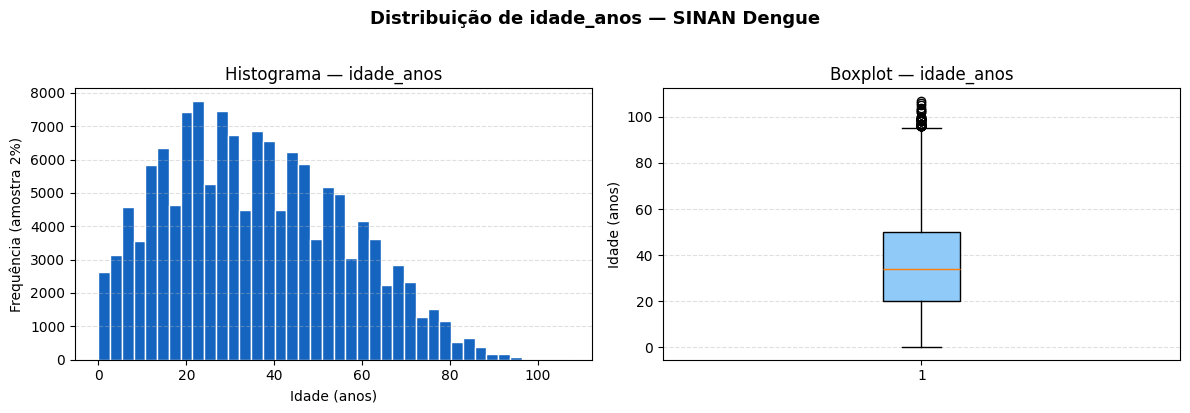

In [7]:
# Amostra para visualização (evita trazer milhões de pontos para o driver)
amostra_idade = df.select('idade_anos').sample(fraction=0.02, seed=42).toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(amostra_idade['idade_anos'], bins=40, color='#1565C0', edgecolor='white')
ax1.set_xlabel('Idade (anos)')
ax1.set_ylabel('Frequência (amostra 2%)')
ax1.set_title('Histograma — idade_anos')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2.boxplot(amostra_idade['idade_anos'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#90CAF9'))
ax2.set_ylabel('Idade (anos)')
ax2.set_title('Boxplot — idade_anos')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribuição de idade_anos — SINAN Dengue', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/eda_idade.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Frequência das variáveis binárias

Para cada variável binária (sexo, sintomas e comorbidades), calcula-se a contagem de 0/1 e o percentual de ocorrência (proporção de valores = 1). Calculado em uma única `agg()` para evitar múltiplos scans do dataset.


In [8]:
agg_exprs = []
for v in BINARIAS:
    agg_exprs.append(F.sum(F.when(col(v) == 1, 1).otherwise(0)).alias(f'{v}__1'))
    agg_exprs.append(F.sum(F.when(col(v) == 0, 1).otherwise(0)).alias(f'{v}__0'))

agg_result = df.agg(*agg_exprs).toPandas().iloc[0]

freq_binarias = []
for v in BINARIAS:
    n1 = int(agg_result[f'{v}__1'])
    n0 = int(agg_result[f'{v}__0'])
    pct = n1 / total * 100
    freq_binarias.append({'variavel': v, 'qtd_0': n0, 'qtd_1': n1, 'pct_ocorrencia': round(pct, 2)})

df_freq = pd.DataFrame(freq_binarias)
print(df_freq.to_string(index=False))

  variavel   qtd_0   qtd_1  pct_ocorrencia
 is_mulher 3147889 3742098           54.31
     FEBRE  956573 5933414           86.12
   MIALGIA 1350594 5539393           80.40
  CEFALEIA 1372075 5517912           80.09
    VOMITO 5069242 1820745           26.43
    NAUSEA 3952503 2937484           42.63
 DOR_RETRO 4696715 2193272           31.83
  EXANTEMA 6163143  726844           10.55
LEUCOPENIA 6579879  310108            4.50
  DIABETES 6595717  294270            4.27
HIPERTENSA 6199803  690184           10.02
     RENAL 6856243   33744            0.49
 HEPATOPAT 6854838   35149            0.51
 HEMATOLOG 6854041   35946            0.52


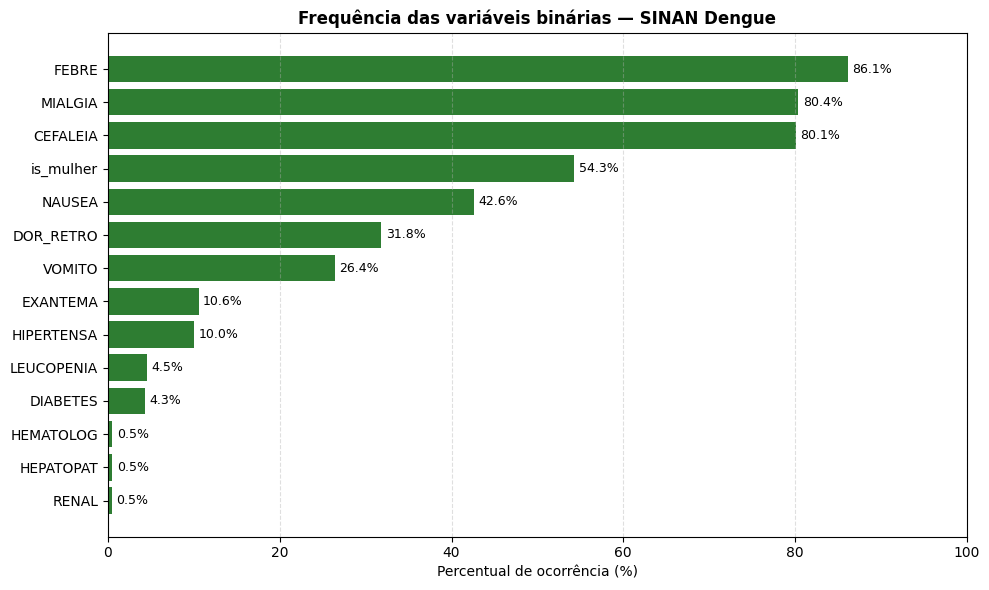

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
df_freq_sorted = df_freq.sort_values('pct_ocorrencia', ascending=True)
ax.barh(df_freq_sorted['variavel'], df_freq_sorted['pct_ocorrencia'], color='#2E7D32')

for i, (var, pct) in enumerate(zip(df_freq_sorted['variavel'], df_freq_sorted['pct_ocorrencia'])):
    ax.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Percentual de ocorrência (%)')
ax.set_title('Frequência das variáveis binárias — SINAN Dengue', fontweight='bold')
ax.set_xlim(0, 100)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/eda_freq_binarias.png', dpi=150)
plt.show()

## 6. Ranking de sintomas por prevalência


In [10]:
df_sintomas = df_freq[df_freq['variavel'].isin(SINTOMAS)] \
    .sort_values('pct_ocorrencia', ascending=False) \
    .reset_index(drop=True)

print('Ranking de sintomas:')
print(df_sintomas[['variavel', 'pct_ocorrencia']].rename(
    columns={'variavel': 'Sintoma', 'pct_ocorrencia': '% Ocorrência'}
).to_string(index=False))


Ranking de sintomas:
   Sintoma  % Ocorrência
     FEBRE         86.12
   MIALGIA         80.40
  CEFALEIA         80.09
    NAUSEA         42.63
 DOR_RETRO         31.83
    VOMITO         26.43
  EXANTEMA         10.55
LEUCOPENIA          4.50


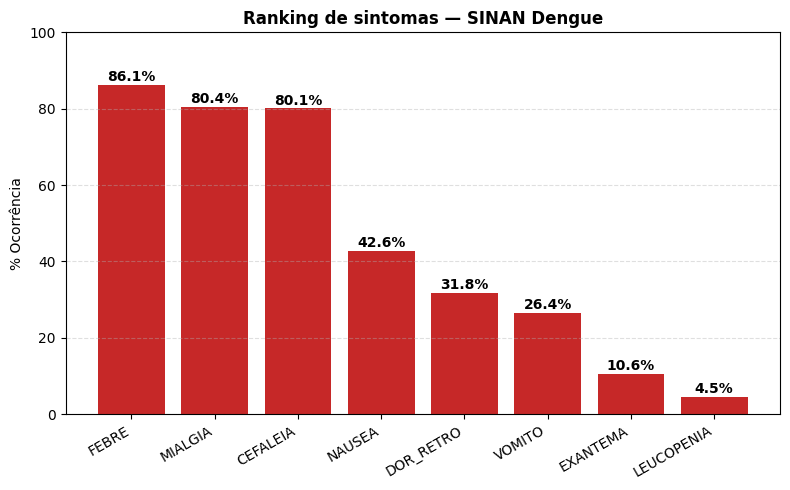

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_sintomas['variavel'], df_sintomas['pct_ocorrencia'], color='#C62828')
for i, pct in enumerate(df_sintomas['pct_ocorrencia']):
    ax.text(i, pct + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('% Ocorrência')
ax.set_title('Ranking de sintomas — SINAN Dengue', fontweight='bold')
ax.set_ylim(0, 100)
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/eda_ranking_sintomas.png', dpi=150)
plt.show()

## 7. Ranking de comorbidades por prevalência


In [12]:
df_comorb = df_freq[df_freq['variavel'].isin(COMORBIDADES)] \
    .sort_values('pct_ocorrencia', ascending=False) \
    .reset_index(drop=True)

print('Ranking de comorbidades:')
print(df_comorb[['variavel', 'pct_ocorrencia']].rename(
    columns={'variavel': 'Comorbidade', 'pct_ocorrencia': '% Ocorrência'}
).to_string(index=False))

Ranking de comorbidades:
Comorbidade  % Ocorrência
 HIPERTENSA         10.02
   DIABETES          4.27
  HEMATOLOG          0.52
  HEPATOPAT          0.51
      RENAL          0.49


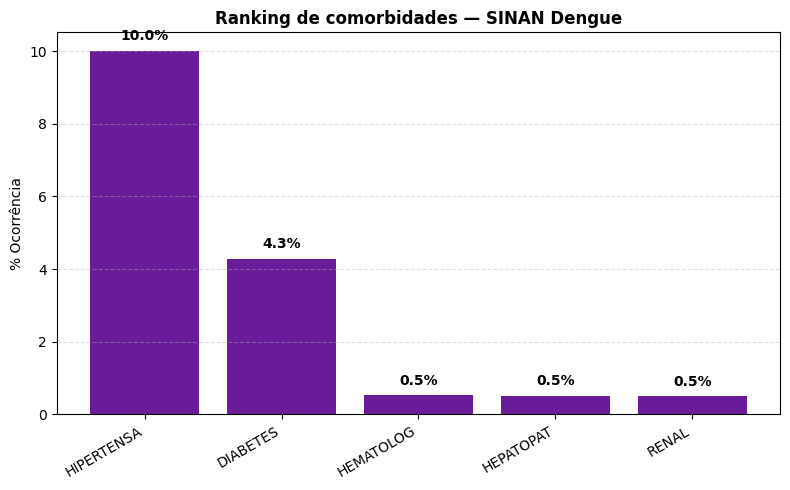

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_comorb['variavel'], df_comorb['pct_ocorrencia'], color='#6A1B9A')
for i, pct in enumerate(df_comorb['pct_ocorrencia']):
    ax.text(i, pct + 0.3, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('% Ocorrência')
ax.set_title('Ranking de comorbidades — SINAN Dengue', fontweight='bold')
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/eda_ranking_comorbidades.png', dpi=150)
plt.show()

## 8. Correlação entre variáveis

Utiliza-se **correlação de Spearman**, baseada em postos (ranks), em vez de Pearson. Pearson assume relação linear entre variáveis contínuas; aqui, 14 das 15 variáveis são binárias, e Spearman captura associações monotônicas sem exigir esse pressuposto — é a escolha mais defensável para um conjunto dominado por variáveis 0/1.

> **Nota sobre PCA (Seção de Conclusões):** o PCA, usado na etapa de mineração, também foi originalmente concebido para variáveis contínuas. Com 14 variáveis binárias e 1 quantitativa, ele funciona como técnica auxiliar de redução de dimensionalidade — não porque os dados sejam o cenário ideal para PCA, mas porque ainda permite compactar redundância entre sintomas/comorbidades correlacionados antes do `BisectingKMeans`. Essa análise de correlação é o que vai mostrar se essa redundância de fato existe.


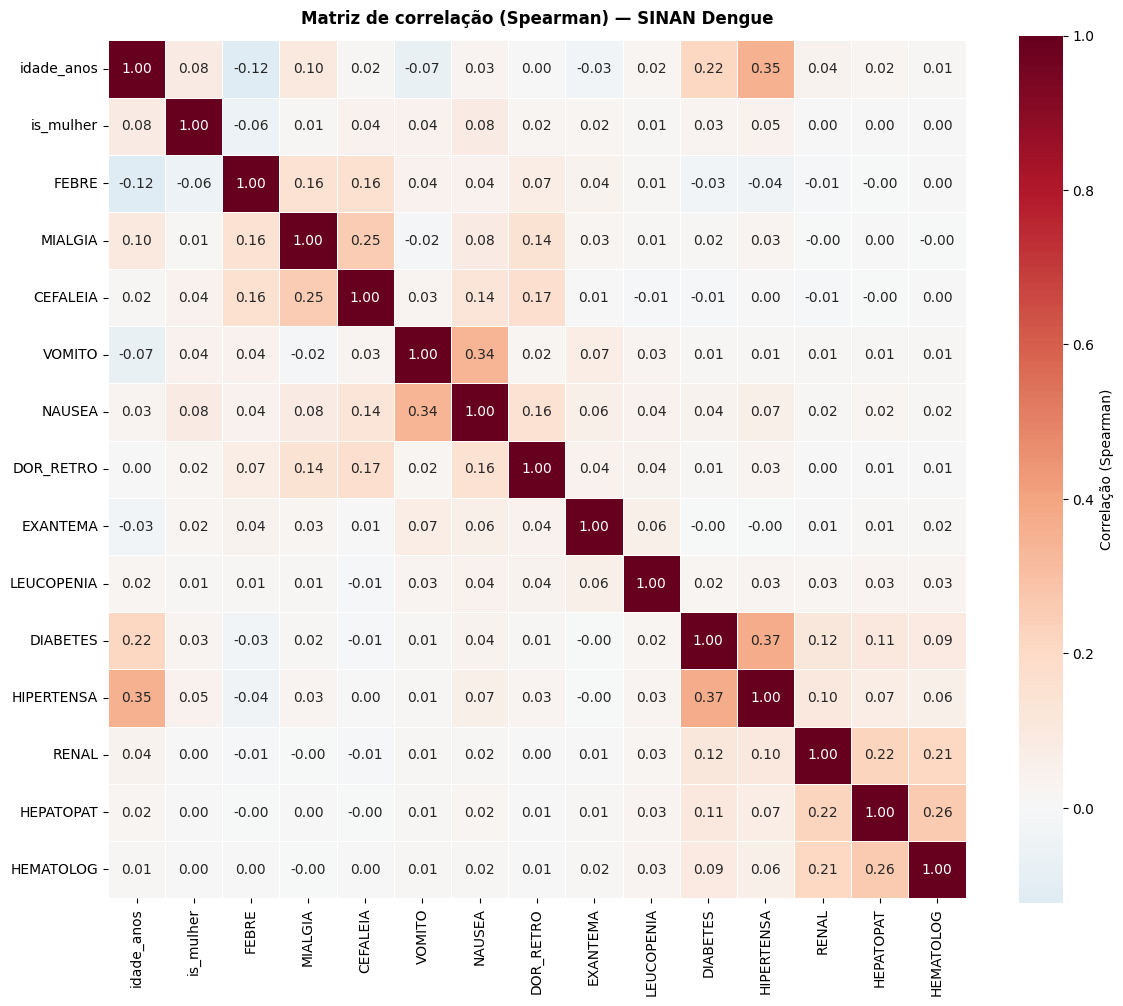

In [14]:
# Amostra para cálculo de correlação (Spearman via pandas)
amostra_corr = df.select(['idade_anos'] + BINARIAS).sample(fraction=0.02, seed=42).toPandas()

corr_spearman = amostra_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlação (Spearman)'}, ax=ax)
ax.set_title('Matriz de correlação (Spearman) — SINAN Dengue', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('/content/eda_correlacao.png', dpi=150)
plt.show()

In [15]:
# Pares com correlação mais forte (exceto diagonal)
corr_pairs = corr_spearman.where(
    ~np.eye(len(corr_spearman), dtype=bool)
).stack().reset_index()
corr_pairs.columns = ['var_1', 'var_2', 'correlacao']

# Remove duplicados (A-B e B-A)
corr_pairs['par'] = corr_pairs.apply(lambda r: tuple(sorted([r.var_1, r.var_2])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset='par').drop(columns='par')

top_corr = corr_pairs.reindex(corr_pairs['correlacao'].abs().sort_values(ascending=False).index).head(10)

print('Top 10 pares com correlação mais forte (|Spearman|):')
print(top_corr.to_string(index=False))

Top 10 pares com correlação mais forte (|Spearman|):
     var_1      var_2  correlacao
  DIABETES HIPERTENSA    0.371832
idade_anos HIPERTENSA    0.351355
    VOMITO     NAUSEA    0.339101
 HEPATOPAT  HEMATOLOG    0.260036
   MIALGIA   CEFALEIA    0.253296
     RENAL  HEPATOPAT    0.219642
idade_anos   DIABETES    0.218350
     RENAL  HEMATOLOG    0.210173
  CEFALEIA  DOR_RETRO    0.167598
     FEBRE   CEFALEIA    0.161292


## 9. Relação exploratória com `HOSPITALIZ`

**Apenas exploração — `HOSPITALIZ` não entra na clusterização.** O objetivo é entender, antes da mineração, quais fatores parecem mais associados à hospitalização. Isso também antecipa o tipo de validação epidemiológica que será feita depois: *os clusters formados sem hospitalização apresentam taxas diferentes dela?*


In [16]:
# ── 9.1 idade_anos × HOSPITALIZ ──
print('idade_anos × HOSPITALIZ — média de idade por grupo:')
df.groupBy('HOSPITALIZ').agg(
    F.count('*').alias('n'),
    F.round(F.mean('idade_anos'), 1).alias('idade_media'),
    F.round(F.expr('percentile_approx(idade_anos, 0.5)'), 1).alias('idade_mediana'),
).orderBy('HOSPITALIZ').show()

idade_anos × HOSPITALIZ — média de idade por grupo:
+----------+-------+-----------+-------------+
|HOSPITALIZ|      n|idade_media|idade_mediana|
+----------+-------+-----------+-------------+
|         0|6583805|       35.8|         34.0|
|         1| 306182|       40.9|         40.0|
+----------+-------+-----------+-------------+



{'whiskers': [<matplotlib.lines.Line2D at 0x7fa6c8b7cdd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fa6c8b7d3d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fa6c8b7cb30>,
 'medians': [<matplotlib.lines.Line2D at 0x7fa6c8b7da00>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fa6c8b7dd00>,
 'means': []}

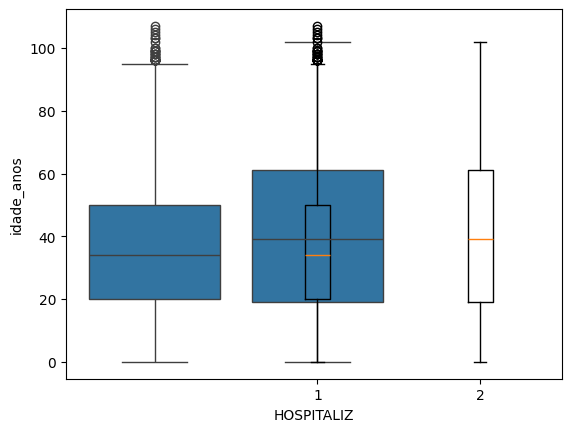

In [17]:
sample_pd = df.select('HOSPITALIZ', 'idade_anos').sample(fraction=0.02, seed=42).toPandas()
sns.boxplot(
    data=sample_pd,
    x='HOSPITALIZ',
    y='idade_anos'
)
plt.boxplot([
    sample_pd[sample_pd['HOSPITALIZ']==0]['idade_anos'],
    sample_pd[sample_pd['HOSPITALIZ']==1]['idade_anos']
])

In [18]:
# ── 9.2 sexo × HOSPITALIZ ──
print('is_mulher × HOSPITALIZ:')
df.groupBy('is_mulher', 'HOSPITALIZ').count() \
    .withColumn('pct', F.round(col('count') / total * 100, 2)) \
    .orderBy('is_mulher', 'HOSPITALIZ').show()

is_mulher × HOSPITALIZ:
+---------+----------+-------+-----+
|is_mulher|HOSPITALIZ|  count|  pct|
+---------+----------+-------+-----+
|        0|         0|3007266|43.65|
|        0|         1| 140623| 2.04|
|        1|         0|3576539|51.91|
|        1|         1| 165559|  2.4|
+---------+----------+-------+-----+



In [19]:
# ── 9.3 sintomas × HOSPITALIZ — taxa de hospitalização quando sintoma presente vs ausente ──
agg_sint_hosp = []
for v in SINTOMAS:
    agg_sint_hosp.append(
        F.round(F.mean(F.when(col(v) == 1, col('HOSPITALIZ'))) * 100, 2).alias(f'{v}__presente')
    )
    agg_sint_hosp.append(
        F.round(F.mean(F.when(col(v) == 0, col('HOSPITALIZ'))) * 100, 2).alias(f'{v}__ausente')
    )

result_sint = df.agg(*agg_sint_hosp).toPandas().iloc[0]

tabela_sint_hosp = pd.DataFrame([
    {'sintoma': v,
     'hospitaliz_pct_presente': result_sint[f'{v}__presente'],
     'hospitaliz_pct_ausente': result_sint[f'{v}__ausente']}
    for v in SINTOMAS
])
tabela_sint_hosp['diferenca_pp'] = (
    tabela_sint_hosp['hospitaliz_pct_presente'] - tabela_sint_hosp['hospitaliz_pct_ausente']
).round(2)
tabela_sint_hosp = tabela_sint_hosp.sort_values('diferenca_pp', ascending=False)

print('Sintomas × Taxa de hospitalização (%) — presente vs ausente:')
print(tabela_sint_hosp.to_string(index=False))

Sintomas × Taxa de hospitalização (%) — presente vs ausente:
   sintoma  hospitaliz_pct_presente  hospitaliz_pct_ausente  diferenca_pp
LEUCOPENIA                    15.69                    3.91         11.78
    VOMITO                     6.37                    3.75          2.62
  EXANTEMA                     5.35                    4.34          1.01
    NAUSEA                     4.78                    4.19          0.59
     FEBRE                     4.28                    5.43         -1.15
 DOR_RETRO                     3.29                    4.98         -1.69
   MIALGIA                     4.11                    5.82         -1.71
  CEFALEIA                     3.70                    7.44         -3.74


In [20]:
# ── 9.4 comorbidades × HOSPITALIZ — mesma lógica ──
agg_com_hosp = []
for v in COMORBIDADES:
    agg_com_hosp.append(
        F.round(F.mean(F.when(col(v) == 1, col('HOSPITALIZ'))) * 100, 2).alias(f'{v}__presente')
    )
    agg_com_hosp.append(
        F.round(F.mean(F.when(col(v) == 0, col('HOSPITALIZ'))) * 100, 2).alias(f'{v}__ausente')
    )

result_com = df.agg(*agg_com_hosp).toPandas().iloc[0]

tabela_com_hosp = pd.DataFrame([
    {'comorbidade': v,
     'hospitaliz_pct_presente': result_com[f'{v}__presente'],
     'hospitaliz_pct_ausente': result_com[f'{v}__ausente']}
    for v in COMORBIDADES
])
tabela_com_hosp['diferenca_pp'] = (
    tabela_com_hosp['hospitaliz_pct_presente'] - tabela_com_hosp['hospitaliz_pct_ausente']
).round(2)
tabela_com_hosp = tabela_com_hosp.sort_values('diferenca_pp', ascending=False)

print('Comorbidades × Taxa de hospitalização (%) — presente vs ausente:')
print(tabela_com_hosp.to_string(index=False))


Comorbidades × Taxa de hospitalização (%) — presente vs ausente:
comorbidade  hospitaliz_pct_presente  hospitaliz_pct_ausente  diferenca_pp
      RENAL                    15.60                    4.39         11.21
  HEMATOLOG                    11.15                    4.41          6.74
   DIABETES                     9.75                    4.21          5.54
  HEPATOPAT                     9.60                    4.42          5.18
 HIPERTENSA                     8.47                    4.00          4.47


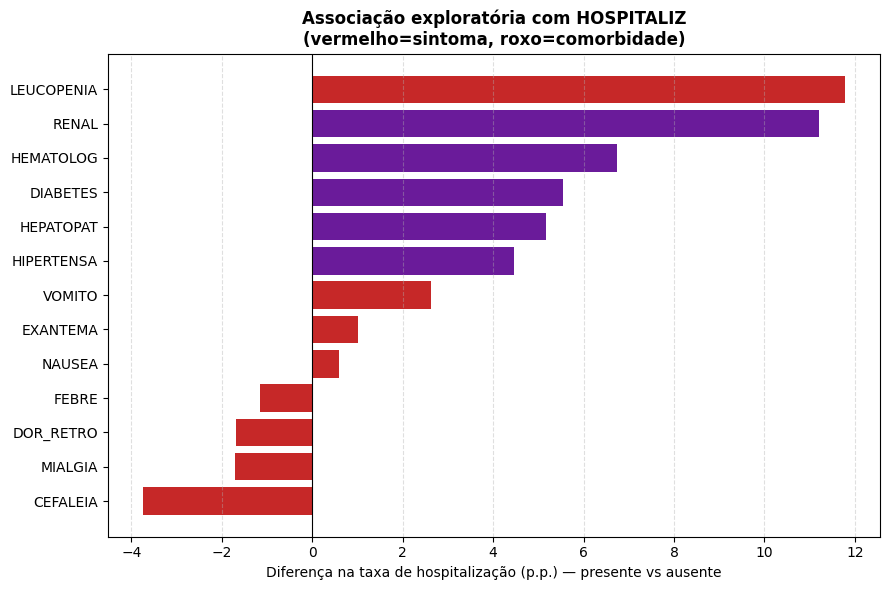

In [21]:
# ── Gráfico: diferença de taxa de hospitalização (presente - ausente) ──
tabela_geral = pd.concat([
    tabela_sint_hosp.rename(columns={'sintoma': 'variavel'}),
    tabela_com_hosp.rename(columns={'comorbidade': 'variavel'}),
]).sort_values('diferenca_pp', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
cores = ['#C62828' if x in SINTOMAS else '#6A1B9A' for x in tabela_geral['variavel']]
ax.barh(tabela_geral['variavel'], tabela_geral['diferenca_pp'], color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Diferença na taxa de hospitalização (p.p.) — presente vs ausente')
ax.set_title('Associação exploratória com HOSPITALIZ\n(vermelho=sintoma, roxo=comorbidade)', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/eda_hospitaliz_assoc.png', dpi=150)
plt.show()

## 10. Distribuição regional — `REGIAO`


In [22]:
df_regiao = df.groupBy('REGIAO').count() \
    .withColumn('pct', F.round(col('count') / total * 100, 2)) \
    .orderBy(F.desc('count')).toPandas()

print('Distribuição regional:')
print(df_regiao.to_string(index=False))

Distribuição regional:
      REGIAO   count   pct
     Sudeste 4124179 59.86
         Sul 1449716 21.04
Centro-Oeste  806773 11.71
    Nordeste  404055  5.86
       Norte  105264  1.53


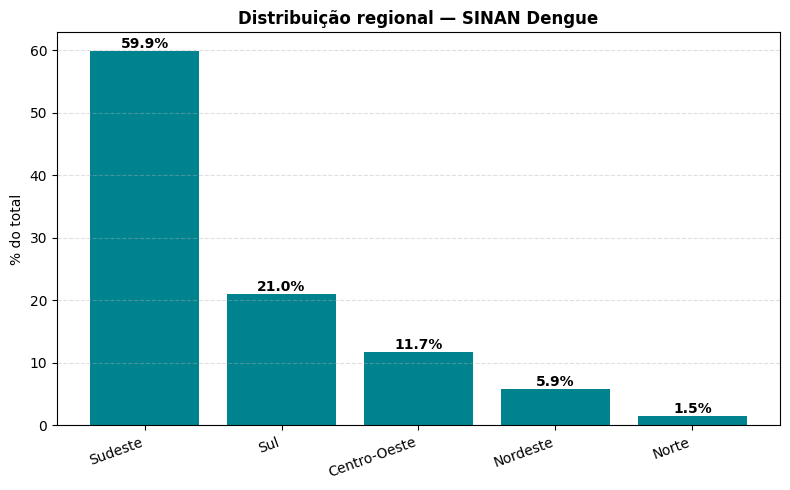

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_regiao['REGIAO'], df_regiao['pct'], color='#00838F')
for i, pct in enumerate(df_regiao['pct']):
    ax.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('% do total')
ax.set_title('Distribuição regional — SINAN Dengue', fontweight='bold')
plt.xticks(rotation=20, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/eda_regiao.png', dpi=150)
plt.show()

## 11. Conclusões da EDA

**Importante:** as observações abaixo são descritivas. Não representam relações causais, não constituem clusters, e não substituem a validação estatística da etapa de mineração.


In [24]:
print('=' * 65)
print('RESUMO DA EDA')
print('=' * 65)

print(f'\nDataset: {total:,} registros, {len(df.columns)} colunas')
print(f'Variáveis quantitativas : 1 (idade_anos)')
print(f'Variáveis binárias      : {len(BINARIAS)}')
print(f'Variáveis de desfecho   : {len(DESFECHO_COLS)} (não entram na mineração)')

print(f'\nIdade — média: {stats_idade.media:.1f} anos, mediana: {stats_idade.mediana:.1f}, '
      f'IQR: [{stats_idade.q1:.0f}, {stats_idade.q3:.0f}]')

print(f'\nSintoma mais frequente     : {df_sintomas.iloc[0]["variavel"]} ({df_sintomas.iloc[0]["pct_ocorrencia"]:.1f}%)')
print(f'Sintoma menos frequente    : {df_sintomas.iloc[-1]["variavel"]} ({df_sintomas.iloc[-1]["pct_ocorrencia"]:.1f}%)')
print(f'Comorbidade mais frequente : {df_comorb.iloc[0]["variavel"]} ({df_comorb.iloc[0]["pct_ocorrencia"]:.1f}%)')

print(f'\nPar mais correlacionado (Spearman): '
      f'{top_corr.iloc[0].var_1} × {top_corr.iloc[0].var_2} = {top_corr.iloc[0].correlacao:.2f}')

print(f'\nVariável mais associada a HOSPITALIZ (maior diferença p.p.): '
      f'{tabela_geral.iloc[-1]["variavel"]} ({tabela_geral.iloc[-1]["diferenca_pp"]:+.1f} p.p.)')

print(f'\nRegião com mais registros: {df_regiao.iloc[0]["REGIAO"]} ({df_regiao.iloc[0]["pct"]:.1f}%)')

RESUMO DA EDA

Dataset: 6,889,987 registros, 21 colunas
Variáveis quantitativas : 1 (idade_anos)
Variáveis binárias      : 14
Variáveis de desfecho   : 4 (não entram na mineração)

Idade — média: 36.0 anos, mediana: 34.0, IQR: [20, 50]

Sintoma mais frequente     : FEBRE (86.1%)
Sintoma menos frequente    : LEUCOPENIA (4.5%)
Comorbidade mais frequente : HIPERTENSA (10.0%)

Par mais correlacionado (Spearman): DIABETES × HIPERTENSA = 0.37

Variável mais associada a HOSPITALIZ (maior diferença p.p.): LEUCOPENIA (+11.8 p.p.)

Região com mais registros: Sudeste (59.9%)


### Síntese

O dataset reúne **1 variável quantitativa** (`idade_anos`) e **14 variáveis binárias** (1 social — sexo — e 13 clínicas — sintomas e comorbidades), além de 4 variáveis de desfecho (`HOSPITALIZ`, `CLASSI_FIN`, `EVOLUCAO`, `REGIAO`) reservadas para análise posterior.

A análise de correlação (Spearman) mostrou pares de sintomas e/ou comorbidades com associação relevante — esses pares são candidatos naturais à redução de redundância que o PCA buscará capturar na etapa de mineração. Vale reforçar: o PCA não foi concebido para variáveis binárias, mas é utilizado como técnica auxiliar de compactação dada a presença dessas correlações.

A seção de relação com `HOSPITALIZ` indica, de forma exploratória, quais sintomas e comorbidades se associam a taxas de hospitalização mais altas — isso **não** define os clusters, mas estabelece uma expectativa: se a clusterização capturar perfis clínicos coerentes, espera-se que os clusters dominados por essas variáveis também apresentem taxas de hospitalização mais altas na etapa de validação estatística.

**Próximos passos:**
```
EDA (este notebook)
  ↓
mineracao.ipynb — VectorAssembler → StandardScaler → PCA → BisectingKMeans → Silhouette
  ↓
analise_estatistica.ipynb — cluster × HOSPITALIZ / REGIAO / EVOLUCAO / CLASSI_FIN
```


In [25]:
spark.stop()